# 03 · Results and error analysis

Everything here is read from `data/artifacts/evaluation/`, written by `fraudlake evaluate`. Model selection happened on CV; the holdout is the last 20% of time and was opened exactly once.

In [1]:
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
from fraudlake.config import get_settings
S = get_settings()
A = S.artifacts_dir
df = pd.read_parquet(A / "mart" / "training.parquet")
df["txn_ts"] = pd.to_datetime(df["txn_ts"])
print(f"{len(df):,} labelled transactions, {df.shape[1]} columns, fraud rate {df.is_fraud.mean():.3%}")
ev = json.loads((A / "evaluation" / "metrics.json").read_text())
pred = pd.read_parquet(A / "evaluation" / "holdout_predictions.parquet")
best = ev["best_model"]; print("selected model:", best)

590,540 labelled transactions, 481 columns, fraud rate 3.499%
selected model: lightgbm


## Holdout metrics

In [2]:
tbl = pd.DataFrame({k: {"CV PR-AUC": m["cv_pr_auc"], "holdout PR-AUC": m["pr_auc"], "ROC-AUC": m["roc_auc"],
                       "precision@1%": m["precision_at_1pct"], "recall@1%FPR": m["recall_at_1pct_fpr"], "Brier": m["brier"]}
                   for k, m in ev["models"].items()}).T.sort_values("CV PR-AUC", ascending=False).round(4)
ci = ev["models"][best]["pr_auc_ci"]; print(f"{best} holdout PR-AUC {ci['point']:.4f}  95% CI [{ci['lo']:.4f}, {ci['hi']:.4f}]")
tbl

lightgbm holdout PR-AUC 0.5932  95% CI [0.5768, 0.6078]


,CV PR-AUC,holdout PR-AUC,ROC-AUC,precision@1%,recall@1%FPR,Brier
lightgbm,0.6066,0.5932,0.9251,0.9149,0.5036,0.0204
xgboost,0.6003,0.6020,0.9163,0.9245,0.5292,0.0196
catboost,0.5948,0.5672,0.9151,0.8958,0.4919,0.0206
rf,0.5295,0.5257,0.9073,0.8719,0.4497,0.0360


## Precision–recall curves

The curve is the whole story for a review queue: pick a recall target, read off the precision the team will experience.

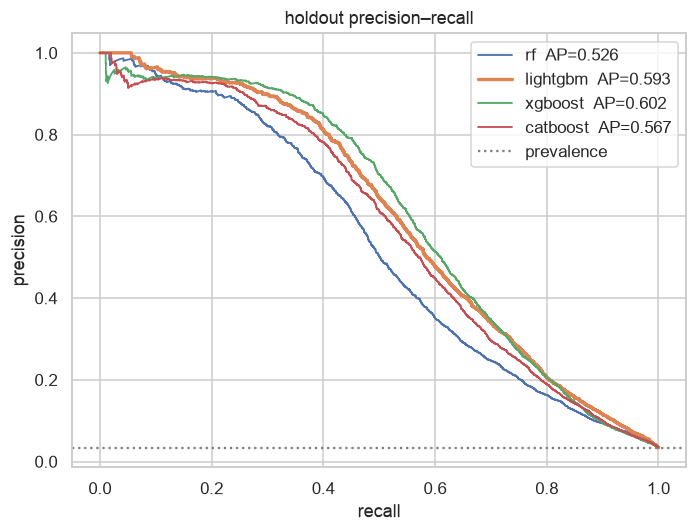

In [3]:
from sklearn.metrics import precision_recall_curve
fig, ax = plt.subplots(figsize=(6.5, 5))
for k in ev["models"]:
    p, r, _ = precision_recall_curve(pred["y"], pred[f"p_{k}"])
    ax.plot(r, p, lw=2.2 if k == best else 1.2, label=f"{k}  AP={ev['models'][k]['pr_auc']:.3f}")
ax.axhline(pred["y"].mean(), color="gray", ls=":", label="prevalence")
ax.set(xlabel="recall", ylabel="precision", title="holdout precision–recall"); ax.legend(); plt.tight_layout()

## Operating point and the cost curve

Expected cost = missed fraud × cost_fn + reviews × cost_fp. The minimum is the threshold the registry stores.

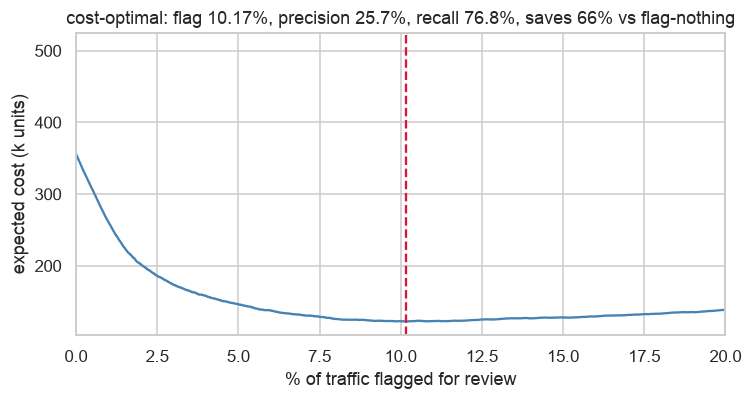

In [4]:
c = ev["models"][best]["cost"]
p = pred[f"p_{best}"].to_numpy(); yv = pred["y"].to_numpy()
order = np.argsort(-p); ys = yv[order]
tp = np.cumsum(ys); fp = np.cumsum(1 - ys); fn = ys.sum() - tp
cost = fn * S.cost_false_negative + fp * S.cost_false_positive
flag = np.arange(1, len(p) + 1) / len(p)
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(flag * 100, cost / 1000, color="steelblue"); ax.axvline(c["flag_rate"] * 100, color="crimson", ls="--")
ax.set(xlabel="% of traffic flagged for review", ylabel="expected cost (k units)", xlim=(0, 20),
       title=f"cost-optimal: flag {c['flag_rate']:.2%}, precision {c['precision']:.1%}, recall {c['recall']:.1%}, saves {c['cost_saving_pct']:.0f}% vs flag-nothing")
plt.tight_layout()

## Calibration

A thresholded score should also be roughly a probability. Deciles of predicted probability versus observed fraud rate.

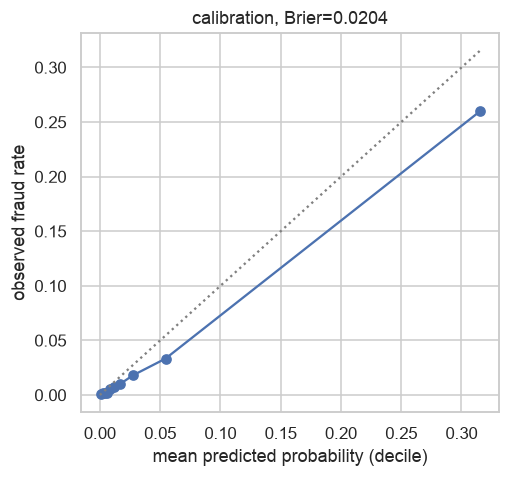

In [5]:
cal = pd.DataFrame(ev["models"][best]["calibration"])
fig, ax = plt.subplots(figsize=(4.8, 4.5))
ax.plot(cal["mean_pred"], cal["frac_pos"], marker="o"); ax.plot([0, cal.mean_pred.max()], [0, cal.mean_pred.max()], ls=":", color="gray")
ax.set(xlabel="mean predicted probability (decile)", ylabel="observed fraud rate", title=f"calibration, Brier={ev['models'][best]['brier']:.4f}"); plt.tight_layout()

## What the model uses

Mean |SHAP| on a holdout sample. Engineered features (velocity, card history, rarity shares) sit alongside the raw anonymised columns.

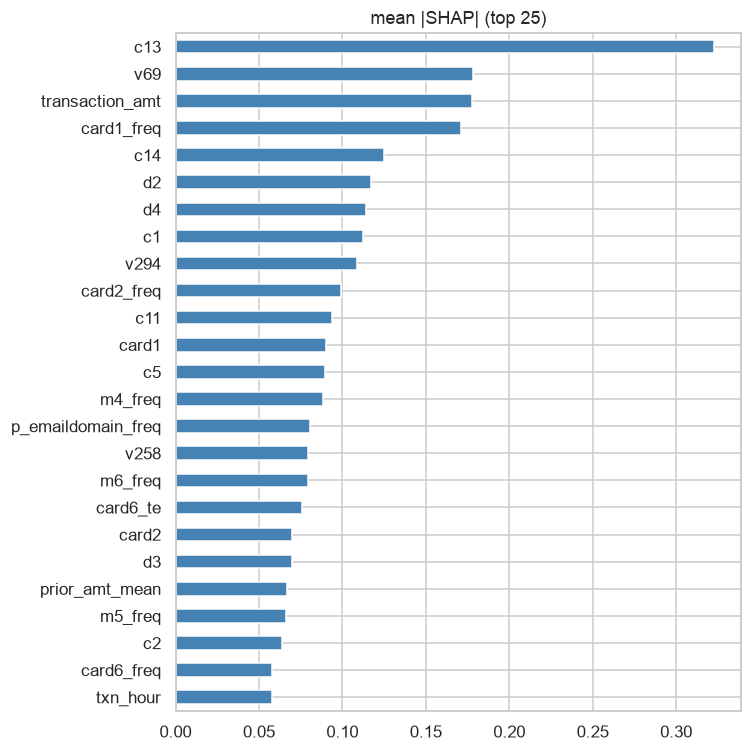

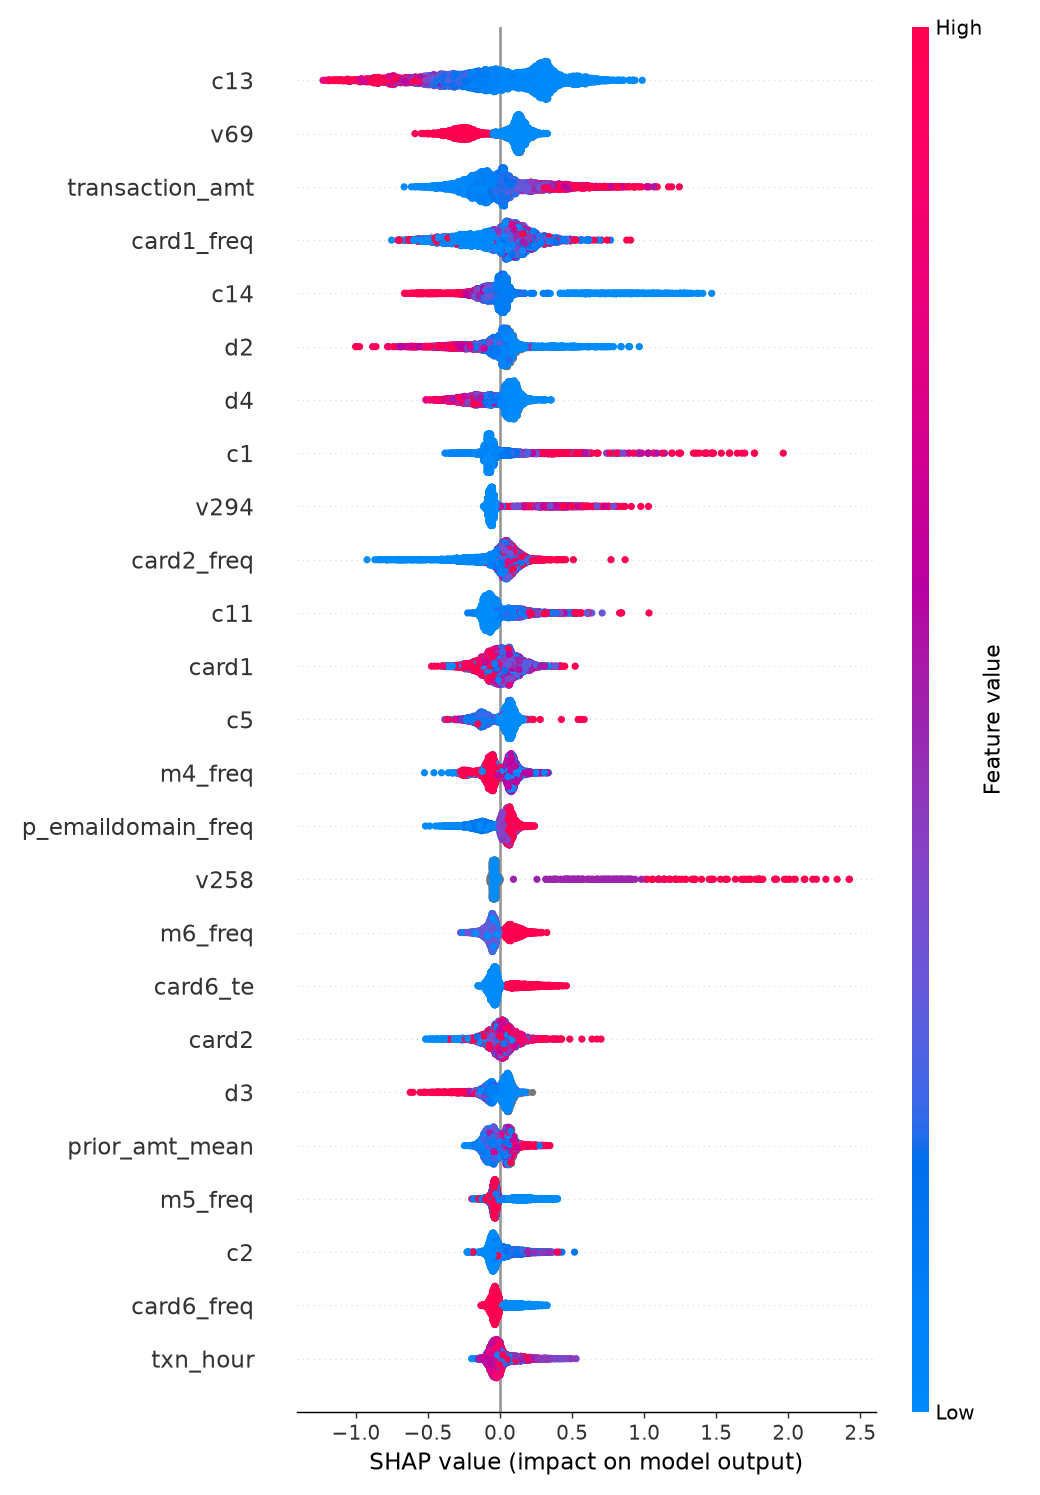

In [6]:
from IPython.display import Image, display
imp = pd.read_csv(A / "evaluation" / "shap_global_importance.csv", index_col=0).iloc[:, 0]
imp.head(25).iloc[::-1].plot.barh(figsize=(7, 7), color="steelblue"); plt.title("mean |SHAP| (top 25)"); plt.tight_layout(); plt.show()
if (A / "evaluation" / "shap_beeswarm.png").exists(): display(Image(str(A / "evaluation" / "shap_beeswarm.png"), width=700))

## Importance stability across folds

If the top features reshuffle every fold, the model is fitting noise. Spearman rank correlation of gain importance between folds for the selected model.

card1_freq          2.8
c13                 3.4
card1               3.8
v294                5.6
transaction_amt     7.0
v258                7.0
c14                 7.4
card2               7.8
d2                  8.4
device_info_te      9.6
c1                 10.6
card2_freq         11.2
c8                 13.0
p_email_norm_te    13.6
prior_amt_mean     14.6
Name: mean rank across folds, dtype: float64

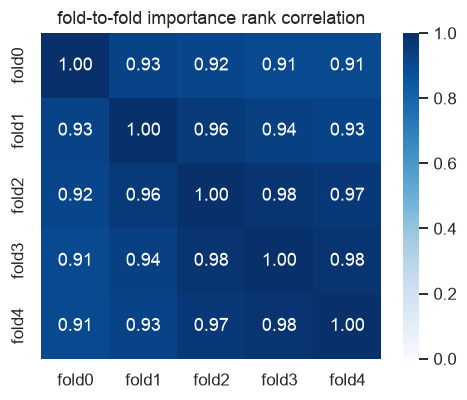

In [7]:
fi = pd.read_csv(A / "models" / best / "fold_importances.csv", index_col=0)
corr = fi.rank().corr(method="spearman")
fig, ax = plt.subplots(figsize=(4.5, 3.8)); sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax); ax.set(title="fold-to-fold importance rank correlation"); plt.tight_layout()
fi.rank(ascending=False).mean(axis=1).sort_values().head(15).rename("mean rank across folds")

## Error analysis: the fraud we miss

The highest-value false negatives at the operating threshold. What do they have in common?

In [8]:
hold = df.merge(pred[["transaction_id", "y", f"p_{best}"]], on="transaction_id")
thr = c["threshold"]
fn_rows = hold[(hold.y == 1) & (hold[f"p_{best}"] < thr)].sort_values("transaction_amt", ascending=False)
print(f"{len(fn_rows):,} missed frauds at threshold {thr:.3f}, total amount {fn_rows.transaction_amt.sum():,.0f}")
fn_rows[["transaction_id", "txn_ts", "transaction_amt", "product_cd", "p_email_norm", "has_identity", "card_txn_idx", "vel_cnt_24h", f"p_{best}"]].head(12)

827 missed frauds at threshold 0.083, total amount 121,902


,transaction_id,txn_ts,transaction_amt,product_cd,p_email_norm,has_identity,card_txn_idx,vel_cnt_24h,p_lightgbm
77361,3550264,2018-05-22 18:25:15,3133.060059,W,gmail,0,0,0,0.070613
18508,3491411,2018-05-02 20:53:53,3076.969971,W,hotmail,0,2,2,0.009950
98840,3571743,2018-05-30 22:10:10,2480.060059,W,gmail,0,1,1,0.038644
79731,3552634,2018-05-23 15:14:16,2259.949951,W,gmail,0,2,2,0.030772
79700,3552603,2018-05-23 15:01:03,2259.949951,W,gmail,0,1,1,0.059396
21135,3494038,2018-05-03 18:07:14,1949.689941,W,gmail,0,0,0,0.015596
3342,3476245,2018-04-27 16:50:07,1795.800049,W,anonymous,0,0,0,0.004789
62274,3535177,2018-05-17 15:14:38,1651.000000,W,cox,0,0,0,0.051304
57428,3530331,2018-05-15 20:43:57,1504.469971,W,yahoo,0,11,11,0.023706
57473,3530376,2018-05-15 20:56:16,1504.469971,W,yahoo,0,12,12,0.012918


In [9]:
cmp = pd.DataFrame({"missed fraud": fn_rows[["has_identity", "is_first_txn_on_card", "card_age_days", "vel_cnt_24h", "transaction_amt"]].mean(),
                    "caught fraud": hold[(hold.y == 1) & (hold[f"p_{best}"] >= thr)][["has_identity", "is_first_txn_on_card", "card_age_days", "vel_cnt_24h", "transaction_amt"]].mean()}).round(3)
cmp

,missed fraud,caught fraud
has_identity,0.345,0.631
is_first_txn_on_card,0.279,0.280
card_age_days,20.459,22.377
vel_cnt_24h,2.177,1.760
transaction_amt,147.403,150.489
